# Sprint 1 · EDA orientado a decisión — detección de eventos adversos en epicrisis MIMIC-IV

**Curso:** MIA-14 Trabajo de Investigación II · **Autor:** Carlos Pérez Pérez · **Entrada:** `data/processed/dataset.parquet` (salida de `src/preprocesado.py`).

Este EDA no describe por describir: cada sección prueba una **hipótesis de riesgo** que, si se confirma, invalidaría o sesgaría el modelo.

| # | Pregunta | Riesgo que vigila |
|---|---|---|
| 1 | ¿Cuánto hay y cómo está balanceado? | desbalance; métrica engañosa |
| 2 | ¿La época de codificación (CIE-9 / CIE-10) separa las clases? | confusor ya detectado en la tesis (drift de codificación) |
| 3 | ¿El largo de la nota separa las clases por sí solo? | atajo (*shortcut*) |
| 4 | ¿Aparecen códigos CIE escritos dentro del texto? | fuga directa de la etiqueta (*label leakage*) |
| 5 | ¿Hay pacientes en train y test a la vez? | fuga por paciente |
| 6 | ¿Cómo se reparten las naturalezas del evento? | clases raras para la etapa 2 |
| 0 | ¿Hay nulos, duplicados u outliers? | calidad de datos |
| 7–8 | ¿Qué variables de contexto se correlacionan con la etiqueta? ¿Cómo se equivoca el baseline? | atajos; tipo de error |

**Regla de datos:** MIMIC-IV está bajo DUA de PhysioNet. Este notebook muestra **solo agregados**; no imprime texto clínico.

In [1]:
import json, re
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
df = pd.read_parquet(RAIZ / "data/processed/dataset.parquet")
resumen = json.loads((RAIZ / "reportes/preprocesado_resumen.json").read_text(encoding="utf-8"))
print(f"{len(df):,} notas · {df.subject_id.nunique():,} pacientes · {df.hadm_id.nunique():,} hospitalizaciones")
print("prevalencia real en MIMIC-IV:", resumen["prevalencia_real"])

70,000 notas · 48,669 pacientes · 70,000 hospitalizaciones
prevalencia real en MIMIC-IV: 0.2012


## 0. Calidad de los datos: nulos, tipos, rangos, duplicados y outliers

In [2]:
df["largo"] = df.text.str.len()
cols = ["note_id", "subject_id", "hadm_id", "y", "epoca", "split", "largo"]
calidad = pd.DataFrame({"tipo": df[cols].dtypes.astype(str), "nulos": df[cols].isna().sum(),
                        "únicos": df[cols].nunique()})
display(calidad)
print("note_id duplicados:", int(df.note_id.duplicated().sum()))
print("hadm_id duplicados:", int(df.hadm_id.duplicated().sum()))
print("textos idénticos repetidos:", int(df.text.duplicated().sum()))
print("rango de largo (caracteres):", int(df.largo.min()), "-", int(df.largo.max()))
q1, q3 = df.largo.quantile([.25, .75]); lim = q3 + 1.5 * (q3 - q1)
print(f"outliers de largo (> Q3 + 1.5·IQR = {lim:,.0f}): {(df.largo > lim).sum():,} ({100*(df.largo > lim).mean():.1f} %)")

,tipo,nulos,únicos
note_id,object,0,70000
subject_id,int64,0,48669
hadm_id,int64,0,70000
y,int64,0,2
epoca,int64,0,2
split,object,0,2
largo,int64,0,18025


note_id duplicados: 0
hadm_id duplicados: 0


textos idénticos repetidos: 0
rango de largo (caracteres): 353 - 58156
outliers de largo (> Q3 + 1.5·IQR = 21,381): 1,933 (2.8 %)


## 1. Volumen y balance de clases

In [3]:
t = pd.crosstab(df.split, df.y, margins=True)
t.columns = ["negativa", "positiva", "total"]
t["% positivas"] = (100 * t.positiva / t.total).round(1)
t

,negativa,positiva,total,% positivas
split,,,,
test,6528,7557,14085,53.7
train,25780,30135,55915,53.9
All,32308,37692,70000,53.8


## 2. Época de codificación por clase (confusor)
Si las positivas fueran mayoritariamente de una época, el modelo aprendería la época y no el evento. La tesis ya lo encontró (AUC inflado a 0.973) y lo corrigió emparejando. Aquí se verifica que el emparejamiento se sostiene y se mide el **AUC de la época sola** como predictor: debe ser ≈ 0.5.

In [4]:
ep = pd.crosstab(df.y, df.epoca, normalize="index").mul(100).round(1)
ep.index = ["negativa", "positiva"]; ep.columns = [f"CIE-{int(c)} %" for c in ep.columns]
display(ep)
print(f"AUC de la época sola: {roc_auc_score(df.y, df.epoca):.3f}")

,CIE-9 %,CIE-10 %
negativa,71.1,28.9
positiva,71.1,28.9


AUC de la época sola: 0.500


## 3. Largo de la nota por clase (atajo)

            count     mean     std    min     25%      50%      75%      max
y                                                                           
negativa  32308.0   9703.0  3807.0  353.0  7033.0   9185.0  11804.0  49439.0
positiva  37692.0  11525.0  5106.0  697.0  7945.0  10717.0  14094.0  58156.0

AUC del largo solo: 0.606


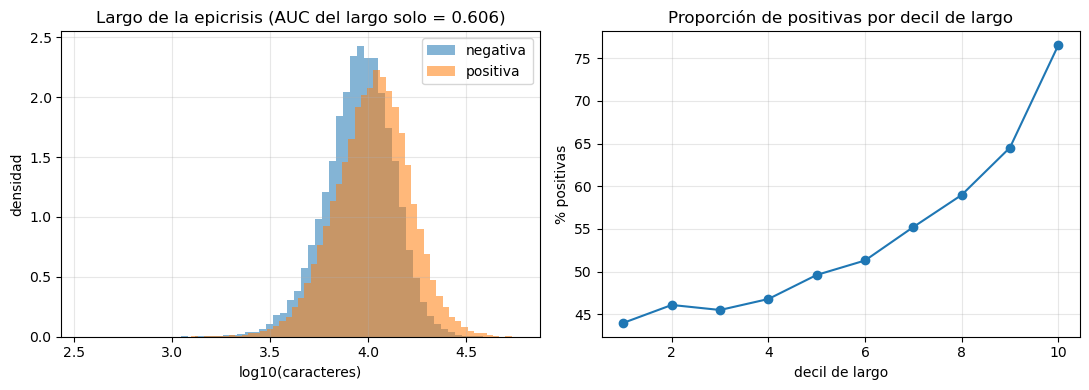

In [5]:
df["largo"] = df.text.str.len()
print(df.groupby("y").largo.describe(percentiles=[.25,.5,.75]).round(0).rename(index={0:"negativa",1:"positiva"}))
auc_largo = roc_auc_score(df.y, df.largo)
print(f"\nAUC del largo solo: {auc_largo:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for y, nombre in [(0, "negativa"), (1, "positiva")]:
    ax[0].hist(np.log10(df.loc[df.y == y, "largo"]), bins=60, alpha=.55, density=True, label=nombre)
ax[0].set(xlabel="log10(caracteres)", ylabel="densidad", title=f"Largo de la epicrisis (AUC del largo solo = {auc_largo:.3f})")
ax[0].legend()
dec = pd.qcut(df.largo, 10, labels=False)
ax[1].plot(range(1, 11), df.groupby(dec).y.mean().values * 100, "o-")
ax[1].set(xlabel="decil de largo", ylabel="% positivas", title="Proporción de positivas por decil de largo")
for a in ax: a.grid(alpha=.3)
fig.tight_layout()
fig.savefig(RAIZ / "reportes/figuras/fig_eda_largo.png", dpi=160)

**Interpretación.** A la izquierda, la distribución del largo de las epicrisis por clase (escala logarítmica): la curva naranja (con evento) está corrida a la derecha. A la derecha, el porcentaje de notas con evento en cada decil de largo.

**Análisis.** Las positivas son más largas (mediana de 10 717 frente a 9 185 caracteres). La proporción de positivas sube de 44.0 % en el decil más corto a 76.5 % en el más largo. El largo solo da un AUC de 0.606.

**Conclusión.** Riesgo moderado de atajo («nota larga = evento»). Decisión 2: evaluar el modelo dentro de cada decil de largo.

## 4. ¿Hay códigos CIE escritos en el texto? (fuga directa)
La etiqueta sale de los códigos CIE de facturación. Si la nota los trajera escritos, el modelo leería la respuesta.

In [6]:
pat_cie10 = re.compile(r"\b[A-TV-Z]\d{2}\.\d{1,4}\b")
pat_cie9 = re.compile(r"\b(?:E|V)?\d{3}\.\d{1,2}\b")
df["tiene_cie10"] = df.text.str.contains(pat_cie10)
df["tiene_cie9_like"] = df.text.str.contains(pat_cie9)
df.groupby("y")[["tiene_cie10", "tiene_cie9_like"]].mean().mul(100).round(2).rename(index={0:"negativa",1:"positiva"})

,tiene_cie10,tiene_cie9_like
y,,
negativa,4.45,27.97
positiva,4.95,33.40


*Nota:* el patrón tipo CIE-9 (`123.45`) también captura números decimales comunes (dosis, laboratorio); por eso la comparación relevante es la **diferencia entre clases**, no el nivel.

## 5. Pacientes y fuga por paciente

In [7]:
npp = df.groupby("subject_id").size()
print("notas por paciente:", npp.describe().round(2).to_dict())
comp = set(df[df.split=="train"].subject_id) & set(df[df.split=="test"].subject_id)
print("pacientes compartidos train/test:", len(comp))

notas por paciente: {'count': 48669.0, 'mean': 1.44, 'std': 1.12, 'min': 1.0, '25%': 1.0, '50%': 1.0, '75%': 1.0, 'max': 27.0}
pacientes compartidos train/test: 0


## 6. Naturaleza del evento entre las positivas (etapa 2)

In [8]:
nat = df[df.y == 1].labels.explode().value_counts()
multi = (df[df.y == 1].labels.str.len() > 1).mean()
print(f"positivas con más de una naturaleza: {100*multi:.1f} %")
(nat.to_frame("notas").assign(pct=lambda d: (100*d.notas/ (df.y==1).sum()).round(2)))

positivas con más de una naturaleza: 5.0 %


,notas,pct
labels,,
Procedimiento,17209,45.66
Cuidado del paciente,10305,27.34
Medicacion,9933,26.35
Dispositivo medico,1198,3.18
Infeccion nosocomial,1007,2.67
Sistema/Organizacion,130,0.34


## 7. Correlaciones simples
El texto no tiene columnas numéricas; se correlacionan la etiqueta y las variables de contexto que podrían ser atajos.

,y (evento),época CIE,largo,log largo,notas del paciente
y (evento),1.000,-0.000,0.182,0.182,0.125
época CIE,-0.000,1.000,0.137,0.137,-0.084
largo,0.182,0.137,1.000,1.000,0.166
log largo,0.182,0.137,1.000,1.000,0.166
notas del paciente,0.125,-0.084,0.166,0.166,1.000


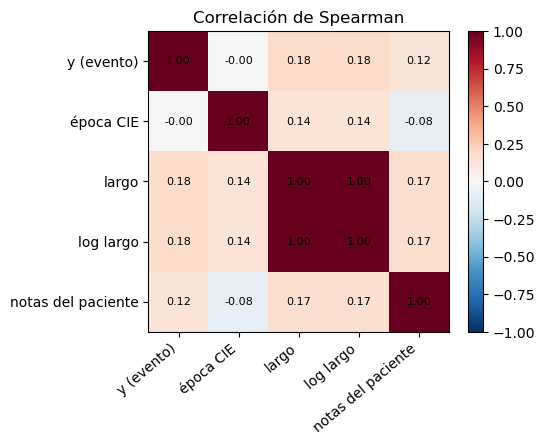

In [9]:
npac = df.groupby("subject_id").note_id.transform("count")
num = pd.DataFrame({"y (evento)": df.y, "época CIE": df.epoca, "largo": df.largo,
                    "log largo": np.log10(df.largo), "notas del paciente": npac})
corr = num.corr(method="spearman").round(3)
display(corr)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=40, ha="right"); ax.set_yticks(range(len(corr)), corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Correlación de Spearman"); fig.colorbar(im); fig.tight_layout()
fig.savefig(RAIZ / "reportes/figuras/fig_eda_correlaciones.png", dpi=160)

**Interpretación.** Correlación de Spearman entre la etiqueta y tres variables de contexto (época CIE, largo y notas del paciente); cerca de 0 significa sin relación.

**Análisis.** La época tiene 0.000 con la etiqueta. El largo (0.182) y las notas por paciente (0.125) tienen correlaciones débiles pero no nulas.

**Conclusión.** El confusor de época está controlado. El largo y la cantidad de hospitalizaciones se vigilan como posibles atajos; la señal debe venir del contenido del texto.

## 8. Matriz de confusión del baseline (test)
Sale de `reportes/baseline_resultados.json`, que genera `src/baseline.py`.

,VN,FP,FN,VP,F1 (+),Recall,PR-AUC,ROC-AUC
modelo,,,,,,,,
dummy_mayoritaria,0,6528,0,7557,0.6984,1.0000,0.5365,0.5000
dummy_estratificada,3035,3493,3367,4190,0.5499,0.5545,0.5414,0.5097
logistica_tfidf,5180,1348,1729,5828,0.7911,0.7712,0.8787,0.8637
referencia_fase9,5026,1502,1796,5761,0.7775,0.7623,0.8610,0.8426


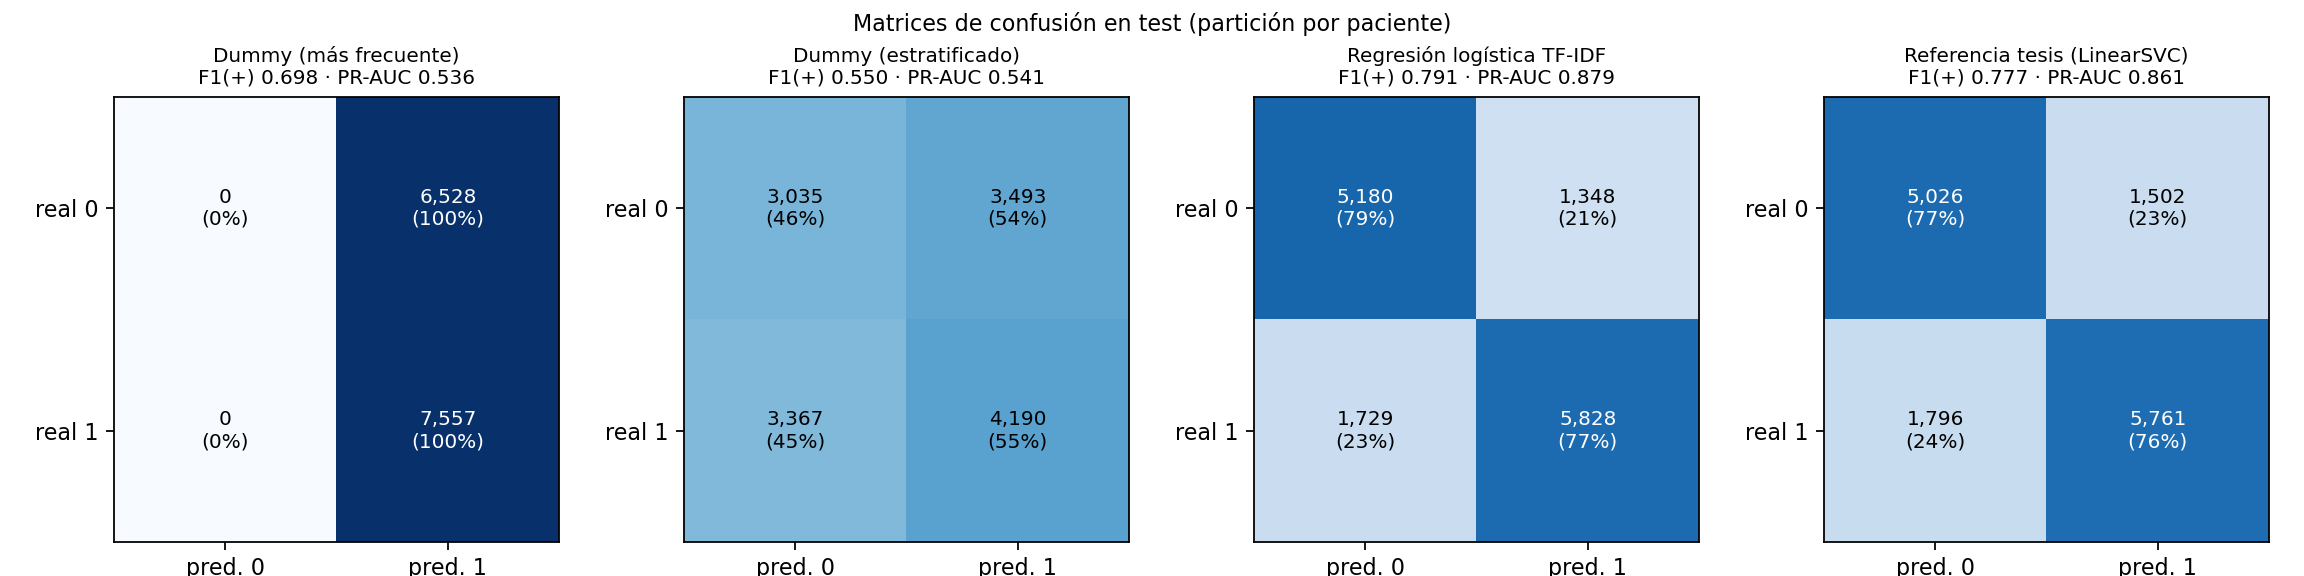

In [10]:
base = json.loads((RAIZ / "reportes/baseline_resultados.json").read_text(encoding="utf-8"))
filas = []
for k, m in base["modelos"].items():
    c = m["matriz"]
    filas.append({"modelo": k, "VN": c["vn"], "FP": c["fp"], "FN": c["fn"], "VP": c["vp"],
                  "F1 (+)": m["f1"], "Recall": m["sensibilidad"], "PR-AUC": m["pr_auc"], "ROC-AUC": m["auc"]})
display(pd.DataFrame(filas).set_index("modelo"))
from IPython.display import Image
Image(filename=str(RAIZ / "reportes/figuras/fig_matrices_confusion.png"))

**Interpretación.** Filas = realidad; columnas = predicción. Arriba a la derecha, falsos positivos; abajo a la izquierda, eventos no detectados. Porcentajes por fila.

**Análisis.** El dummy más frecuente marca todo como evento (recall 100 %, especificidad 0 %). La logística acierta el 79 % de los negativos y detecta el 77 % de los eventos, con 154 falsos positivos y 67 falsos negativos menos que el modelo de la tesis.

**Conclusión.** La logística reduce los dos tipos de error, pero el 23 % de los eventos no se detecta. En vigilancia de seguridad del paciente es el error más costoso, y ajustar el umbral queda pendiente.

## Decisiones accionables para el Sprint 2

Cada decisión cumple los cuatro requisitos de la guía de la semana 3: tiene un verbo, afecta un paso del pipeline, se puede ejecutar ya y tiene un control medible.

| # | Decisión | Paso del pipeline | Por qué (evidencia de este EDA) | Cómo se mide si funcionó |
|---|---|---|---|---|
| 1 | **Adoptar la PR-AUC como métrica central** y reportar F1 (+) y Recall a su lado | Métrica | El dummy que siempre dice «sí» obtiene **F1 (+) = 0.698**, porque el test tiene 53.7 % de positivas: el F1 solo no distingue un modelo útil de uno trivial. El piso de la PR-AUC es la proporción de positivas (0.537) | Tabla de métricas con PR-AUC e IC 95 % en `logs/metrics_baseline.txt`, comparada contra el piso de 0.537 |
| 2 | **Separar la evaluación por deciles de largo** y añadir el largo como variable de control | Split / features | El largo solo da un **AUC de 0.606**, y la proporción de positivas sube de 44.0 % a 76.5 % del decil más corto al más largo: hay riesgo de atajo | PR-AUC dentro de cada decil. Si dentro de los deciles cae mucho frente a la global, el modelo se apoya en el largo |
| 3 | **Enmascarar los patrones de código CIE** en el texto antes de vectorizar | Preprocesado | Códigos con formato CIE-10 en **4.95 %** de las positivas frente a **4.45 %** de las negativas: fuga posible, aunque pequeña | Diferencia de PR-AUC con y sin máscara en la misma partición |

### Otros hallazgos (registrados, sin acción esta semana)
- **Época de codificación:** está controlada; 71.1 / 28.9 % de CIE-9 / CIE-10 en ambas clases y AUC de la época sola = 0.500.
- **Fuga por paciente:** 0 pacientes compartidos entre train y test; 1.44 notas por paciente. La validación cruzada del Sprint 2 debe ser **GroupKFold por paciente** (semana 5 del sílabo).
- **Correlaciones (Spearman):** la etiqueta se asocia con el largo (0.182) y con el número de notas del paciente (0.125); la época queda en 0.000. Los pacientes con más hospitalizaciones tienen más eventos: hay que tenerlo en cuenta al interpretar el modelo.
- **Calidad:** 0 nulos, 0 note_id duplicados, 0 textos repetidos; el largo va de 353 a 58 156 caracteres, con 1 933 outliers (2.8 %) que se conservan porque son notas reales.
- **Etapa 2:** la naturaleza Sistema/Organización tiene solo 130 notas (0.34 %) y no es evaluable con este volumen.
- **Baseline:** la regresión logística (PR-AUC 0.879) supera al modelo de la tesis (0.861). Hay que explicar la diferencia antes de elegir el modelo.

**Limitación:** la etiqueta es débil (códigos CIE de facturación), no una lectura clínica de la nota.